First 10 rows
        Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
0          Afghanistan      36263    1269      25198    9796        106   
1              Albania       4880     144       2745    1991        117   
2              Algeria      27973    1163      18837    7973        616   
3              Andorra        907      52        803      52         10   
4               Angola        950      41        242     667         18   
5  Antigua and Barbuda         86       3         65      18          4   
6            Argentina     167416    3059      72575   91782       4890   
7              Armenia      37390     711      26665   10014         73   
8            Australia      15303     167       9311    5825        368   
9              Austria      20558     713      18246    1599         86   

   New deaths  New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0          10             18                3.50                  69.49   
1         

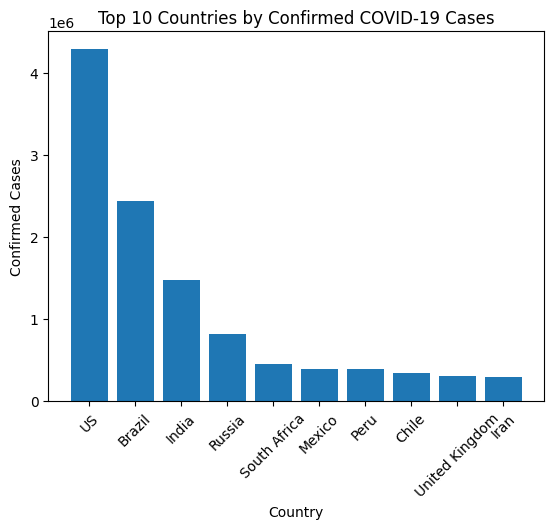

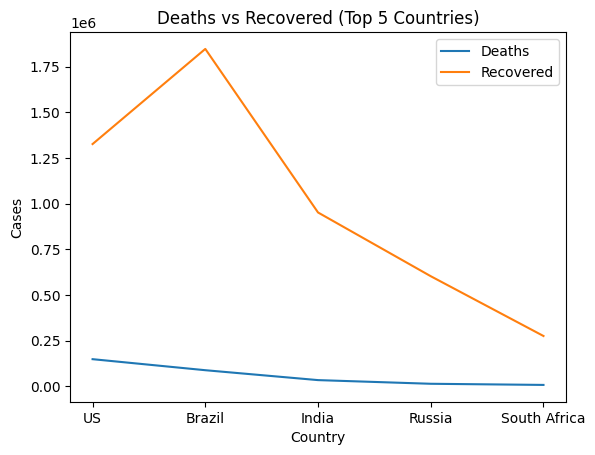

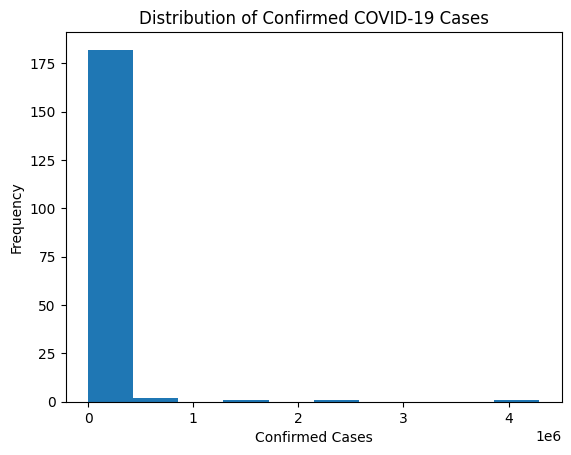

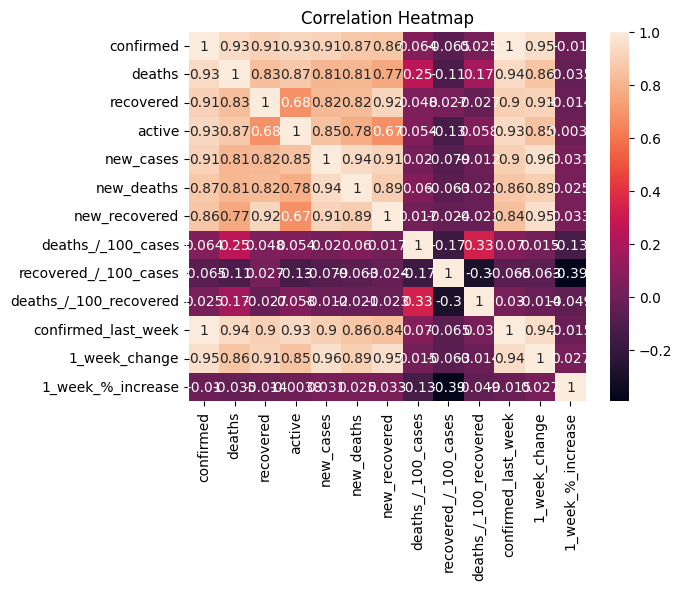

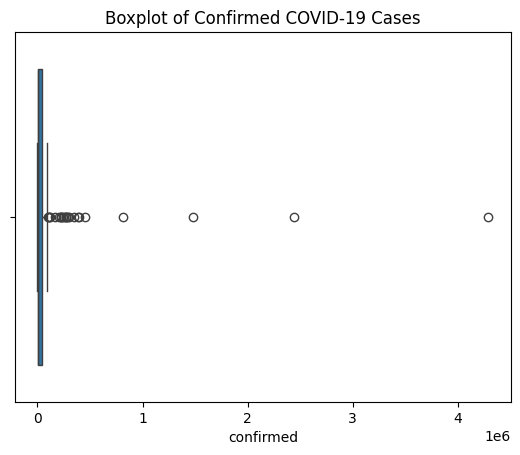

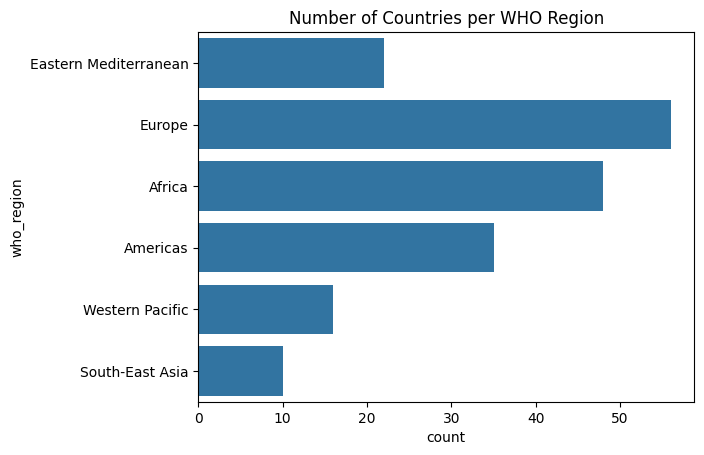


Country with Highest Active Cases:
country/region         US
active_cases      2816444
Name: 173, dtype: object

Country with Lowest Death Rate:
country/region    Bhutan
death_rate           0.0
Name: 19, dtype: object


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("country_wise_latest.csv")

print("First 10 rows")
print(df.head(10))
print("\nLast 5 rows")
print(df.tail())


print("\nDataset Shape:")
print(df.shape)
print("\nColumn Names:")
print(df.columns)


print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())



data_np = df.to_numpy()
print("\nNumPy Array Shape:")
print(data_np.shape)
print("\nFirst 5 rows using NumPy slicing:")
print(data_np[:5])

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
print(df.columns)


numerical_cols = df.select_dtypes(include=np.number).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())
df["active_cases"] = df["confirmed"] - df["deaths"] - df["recovered"]
print("\nActive cases column created successfully.")

confirmed_np = df["confirmed"].to_numpy()
print("\nConfirmed Cases Statistics:")
print("Minimum:", np.min(confirmed_np))
print("Maximum:", np.max(confirmed_np))
print("Mean:", np.mean(confirmed_np))
print("Median:", np.median(confirmed_np))


above_mean = df[df["confirmed"] > np.mean(confirmed_np)]
print("\nCountries with confirmed cases above mean:")
print(above_mean[["country/region", "confirmed"]])

top_10_confirmed = df.sort_values(by="confirmed", ascending=False).head(10)
print("\nTop 10 Countries by Confirmed Cases:")
print(top_10_confirmed[["country/region", "confirmed"]])


bottom_10_deaths = df.sort_values(by="deaths").head(10)
print("\nBottom 10 Countries by Deaths:")
print(bottom_10_deaths[["country/region", "deaths"]])

df["recovery_rate"] = df["recovered"] / df["confirmed"]
df["death_rate"] = df["deaths"] / df["confirmed"]


plt.figure()
plt.bar(top_10_confirmed["country/region"], top_10_confirmed["confirmed"])
plt.xticks(rotation=45)
plt.title("Top 10 Countries by Confirmed COVID-19 Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.show()


top_5 = top_10_confirmed.head(5)

plt.figure()
plt.plot(top_5["country/region"], top_5["deaths"], label="Deaths")
plt.plot(top_5["country/region"], top_5["recovered"], label="Recovered")
plt.legend()
plt.title("Deaths vs Recovered (Top 5 Countries)")
plt.xlabel("Country")
plt.ylabel("Cases")
plt.show()

plt.figure()
plt.hist(df["confirmed"])
plt.title("Distribution of Confirmed COVID-19 Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Frequency")
plt.show()

plt.figure()
sns.heatmap(df[numerical_cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

plt.figure()
sns.boxplot(x=df["confirmed"])
plt.title("Boxplot of Confirmed COVID-19 Cases")
plt.show()

if "who_region" in df.columns:
    plt.figure()
    sns.countplot(y=df["who_region"])
    plt.title("Number of Countries per WHO Region")
    plt.show()

highest_active = df.loc[df["active_cases"].idxmax()]
print("\nCountry with Highest Active Cases:")
print(highest_active[["country/region", "active_cases"]])

lowest_death_rate = df.loc[df["death_rate"].idxmin()]
print("\nCountry with Lowest Death Rate:")
print(lowest_death_rate[["country/region", "death_rate"]])

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("country_wise_latest.csv")

In [35]:
#1
print("First 10 rows")
print(df.head(10))
print("\nLast 5 rows")
print(df.tail())

First 10 rows
        Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
0          Afghanistan      36263    1269      25198    9796        106   
1              Albania       4880     144       2745    1991        117   
2              Algeria      27973    1163      18837    7973        616   
3              Andorra        907      52        803      52         10   
4               Angola        950      41        242     667         18   
5  Antigua and Barbuda         86       3         65      18          4   
6            Argentina     167416    3059      72575   91782       4890   
7              Armenia      37390     711      26665   10014         73   
8            Australia      15303     167       9311    5825        368   
9              Austria      20558     713      18246    1599         86   

   New deaths  New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0          10             18                3.50                  69.49   
1         

In [36]:
#2
print("\nDataset Shape:")
print(df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)


Dataset Shape:
(187, 15)

Column Names:
Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')

Data Types:
Country/Region             object
Confirmed                   int64
Deaths                      int64
Recovered                   int64
Active                      int64
New cases                   int64
New deaths                  int64
New recovered               int64
Deaths / 100 Cases        float64
Recovered / 100 Cases     float64
Deaths / 100 Recovered    float64
Confirmed last week         int64
1 week change               int64
1 week % increase         float64
WHO Region                 object
dtype: object


In [37]:
#3
print("\nMissing Values:")
print(df.isnull().sum())
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())


Missing Values:
Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

Number of Duplicate Rows:
0


In [38]:
#4
data_np = df.to_numpy()
print(data_np.shape)
print("\nFirst 5 rows using NumPy slicing:")
print(data_np[:5])

(187, 15)

First 5 rows using NumPy slicing:
[['Afghanistan' 36263 1269 25198 9796 106 10 18 3.5 69.49 5.04 35526 737
  2.07 'Eastern Mediterranean']
 ['Albania' 4880 144 2745 1991 117 6 63 2.95 56.25 5.25 4171 709 17.0
  'Europe']
 ['Algeria' 27973 1163 18837 7973 616 8 749 4.16 67.34 6.17 23691 4282
  18.07 'Africa']
 ['Andorra' 907 52 803 52 10 0 0 5.73 88.53 6.48 884 23 2.6 'Europe']
 ['Angola' 950 41 242 667 18 1 0 4.32 25.47 16.94 749 201 26.84 'Africa']]


In [39]:
#5
df.columns = (df.columns.str.strip().str.lower().str.replace(" ", "_"))
print(df.columns)

Index(['country/region', 'confirmed', 'deaths', 'recovered', 'active',
       'new_cases', 'new_deaths', 'new_recovered', 'deaths_/_100_cases',
       'recovered_/_100_cases', 'deaths_/_100_recovered',
       'confirmed_last_week', '1_week_change', '1_week_%_increase',
       'who_region'],
      dtype='object')


In [40]:
#6
numerical_cols = df.select_dtypes(include=np.number).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())
print(df.head())


  country/region  confirmed  deaths  recovered  active  new_cases  new_deaths  \
0    Afghanistan      36263    1269      25198    9796        106          10   
1        Albania       4880     144       2745    1991        117           6   
2        Algeria      27973    1163      18837    7973        616           8   
3        Andorra        907      52        803      52         10           0   
4         Angola        950      41        242     667         18           1   

   new_recovered  deaths_/_100_cases  recovered_/_100_cases  \
0             18                3.50                  69.49   
1             63                2.95                  56.25   
2            749                4.16                  67.34   
3              0                5.73                  88.53   
4              0                4.32                  25.47   

   deaths_/_100_recovered  confirmed_last_week  1_week_change  \
0                    5.04                35526            737   
1   

In [41]:
#7
df["active_cases"] = df["confirmed"] - df["deaths"] - df["recovered"]
print(df.head())

  country/region  confirmed  deaths  recovered  active  new_cases  new_deaths  \
0    Afghanistan      36263    1269      25198    9796        106          10   
1        Albania       4880     144       2745    1991        117           6   
2        Algeria      27973    1163      18837    7973        616           8   
3        Andorra        907      52        803      52         10           0   
4         Angola        950      41        242     667         18           1   

   new_recovered  deaths_/_100_cases  recovered_/_100_cases  \
0             18                3.50                  69.49   
1             63                2.95                  56.25   
2            749                4.16                  67.34   
3              0                5.73                  88.53   
4              0                4.32                  25.47   

   deaths_/_100_recovered  confirmed_last_week  1_week_change  \
0                    5.04                35526            737   
1   

In [42]:
#8
confirmed_np = df["confirmed"].to_numpy()
print("Minimum:", np.min(confirmed_np))
print("Maximum:", np.max(confirmed_np))
print("Mean:", np.mean(confirmed_np))
print("Median:", np.median(confirmed_np))
above_mean = df[df["confirmed"] > np.mean(confirmed_np)]
print(above_mean[["country/region", "confirmed"]])

Minimum: 10
Maximum: 4290259
Mean: 88130.935828877
Median: 5059.0
     country/region  confirmed
6         Argentina     167416
13       Bangladesh     226225
23           Brazil    2442375
32           Canada     116458
35            Chile     347923
37         Colombia     257101
52            Egypt      92482
61           France     220352
65          Germany     207112
79            India    1480073
80        Indonesia     100303
81             Iran     293606
82             Iraq     112585
85            Italy     246286
111          Mexico     395489
128        Pakistan     274289
132            Peru     389717
136           Qatar     109597
138          Russia     816680
145    Saudi Arabia     268934
154    South Africa     452529
157           Spain     272421
172          Turkey     227019
173              US    4290259
177  United Kingdom     301708


In [43]:
#9
top_10_confirmed = df.sort_values(by="confirmed", ascending=False).head(10)
print("\nTop 10 Countries by Confirmed Cases:")
print(top_10_confirmed[["country/region", "confirmed"]])

bottom_10_deaths = df.sort_values(by="deaths").head(10)
print("\nBottom 10 Countries by Deaths:")
print(bottom_10_deaths[["country/region", "deaths"]])


Top 10 Countries by Confirmed Cases:
     country/region  confirmed
173              US    4290259
23           Brazil    2442375
79            India    1480073
138          Russia     816680
154    South Africa     452529
111          Mexico     395489
132            Peru     389717
35            Chile     347923
177  United Kingdom     301708
81             Iran     293606

Bottom 10 Countries by Deaths:
    country/region  deaths
30        Cambodia       0
19          Bhutan       0
59            Fiji       0
55         Eritrea       0
49        Dominica       0
75        Holy See       0
68       Greenland       0
69         Grenada       0
94            Laos       0
114       Mongolia       0


In [44]:
#10
df["recovery_rate"] = df["recovered"] / df["confirmed"]
df["death_rate"] = df["deaths"] / df["confirmed"]
display(df.head())

,country/region,confirmed,deaths,recovered,active,new_cases,new_deaths,new_recovered,deaths_/_100_cases,recovered_/_100_cases,deaths_/_100_recovered,confirmed_last_week,1_week_change,1_week_%_increase,who_region,active_cases,recovery_rate,death_rate
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean,9796,0.694868,0.034994
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe,1991,0.562500,0.029508
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa,7973,0.673399,0.041576
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe,52,0.885336,0.057332
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa,667,0.254737,0.043158


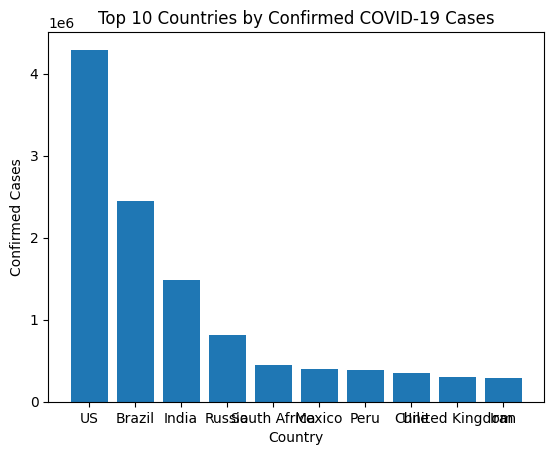

In [45]:
#11
plt.bar(top_10_confirmed["country/region"], top_10_confirmed["confirmed"])
plt.title("Top 10 Countries by Confirmed COVID-19 Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.show()

    country/region  confirmed  deaths  recovered   active  new_cases  \
173             US    4290259  148011    1325804  2816444      56336   
23          Brazil    2442375   87618    1846641   508116      23284   
79           India    1480073   33408     951166   495499      44457   
138         Russia     816680   13334     602249   201097       5607   
154   South Africa     452529    7067     274925   170537       7096   

     new_deaths  new_recovered  deaths_/_100_cases  recovered_/_100_cases  \
173        1076          27941                3.45                  30.90   
23          614          33728                3.59                  75.61   
79          637          33598                2.26                  64.26   
138          85           3077                1.63                  73.74   
154         298           9848                1.56                  60.75   

     deaths_/_100_recovered  confirmed_last_week  1_week_change  \
173                   11.16          

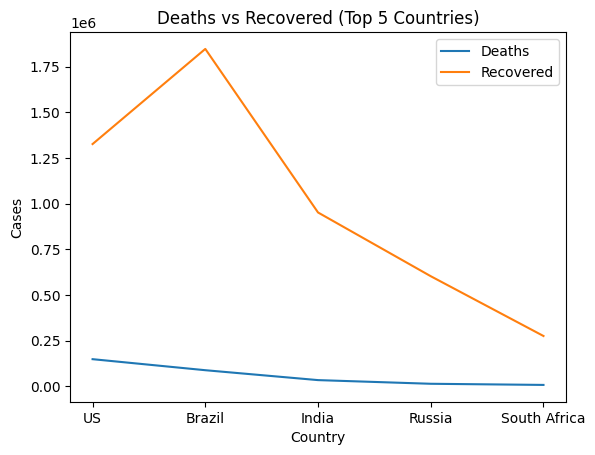

In [46]:
#11
top_5 = top_10_confirmed.head(5)
print(top_5)

plt.figure()
plt.plot(top_5["country/region"], top_5["deaths"], label="Deaths")
plt.plot(top_5["country/region"], top_5["recovered"], label="Recovered")
plt.legend()
plt.title("Deaths vs Recovered (Top 5 Countries)")
plt.xlabel("Country")
plt.ylabel("Cases")
plt.show()

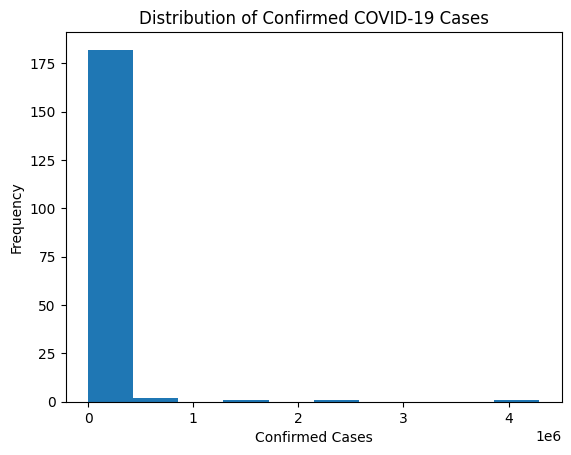

In [47]:
#11
plt.figure()
plt.hist(df["confirmed"])
plt.title("Distribution of Confirmed COVID-19 Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Frequency")
plt.show()

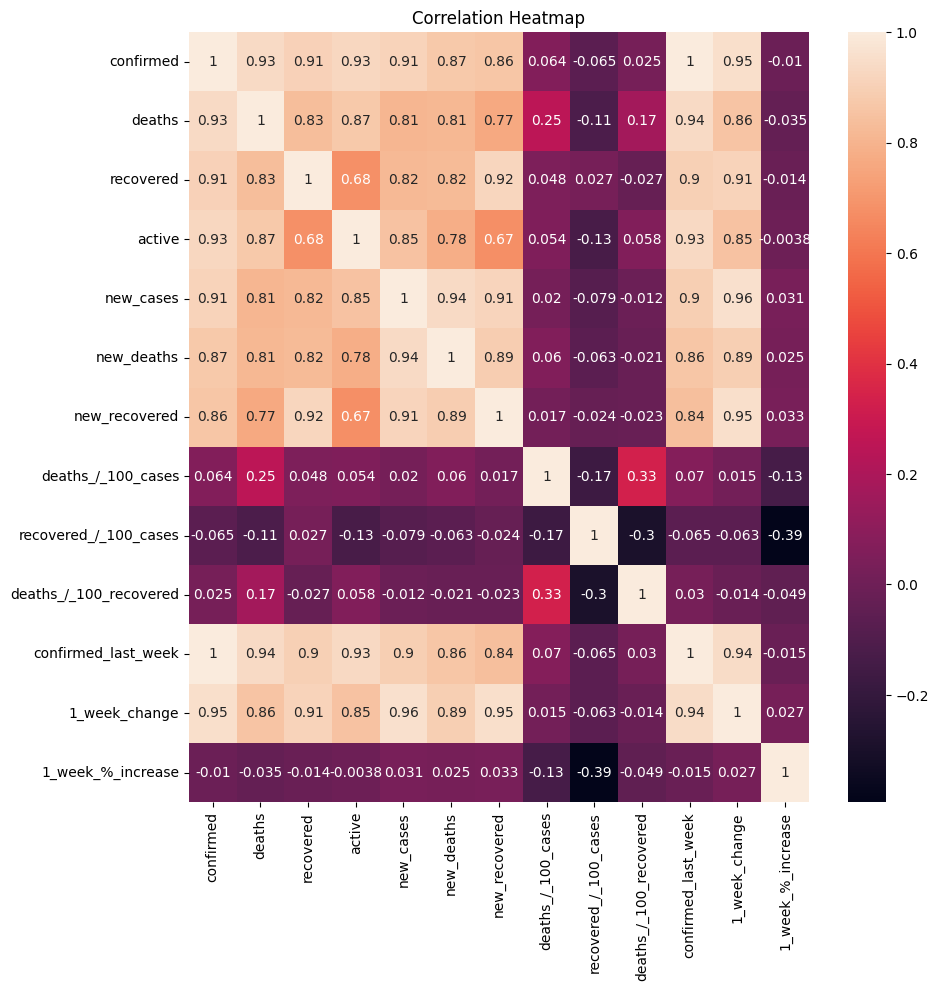

In [53]:
#12
plt.figure(figsize=(10,10))
sns.heatmap(df[numerical_cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

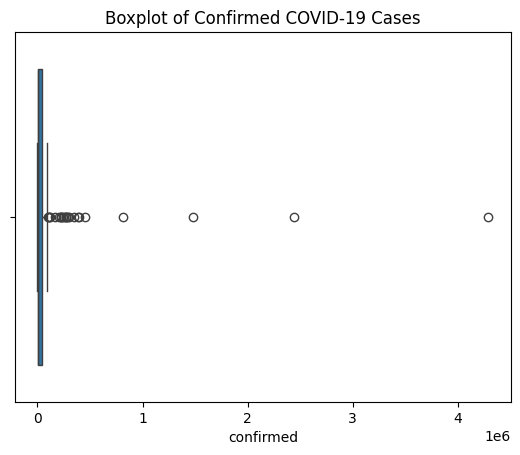

In [49]:
#12
plt.figure()
sns.boxplot(x=df["confirmed"])
plt.title("Boxplot of Confirmed COVID-19 Cases")
plt.show()

In [50]:
#13
highest_active_row=df.sort_values(by='active',ascending=False).iloc[0]
print(highest_active_row)
lowest_death_rate_row=df.sort_values(by='deaths',ascending=True).iloc[0]
print(lowest_death_rate_row)

country/region                  US
confirmed                  4290259
deaths                      148011
recovered                  1325804
active                     2816444
new_cases                    56336
new_deaths                    1076
new_recovered                27941
deaths_/_100_cases            3.45
recovered_/_100_cases         30.9
deaths_/_100_recovered       11.16
confirmed_last_week        3834677
1_week_change               455582
1_week_%_increase            11.88
who_region                Americas
active_cases               2816444
recovery_rate             0.309027
death_rate                0.034499
Name: 173, dtype: object
country/region                   Cambodia
confirmed                             226
deaths                                  0
recovered                             147
active                                 79
new_cases                               1
new_deaths                              0
new_recovered                           4
deaths_/_

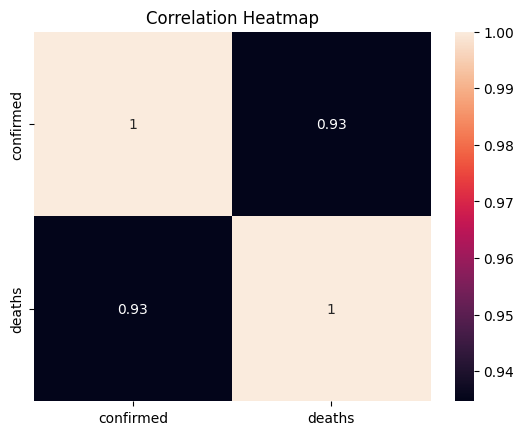

In [51]:
#13
corr=df[['confirmed','deaths']].corr()
sns.heatmap(corr,annot=True)
plt.title("Correlation Heatmap")
plt.show()


In [52]:
df.groupby('who_region')['confirmed'].sum().idxmax()

'Americas'